# Generative AI in the Workplace: Productivity vs. Job Security Anxiety

This notebook loads a **raw Google Form export**, cleans/codes it via `src/preprocessing.py`, validates it, and runs the full analysis: descriptives, correlation, group comparisons (ANOVA), regression, visualizations, and light thematic coding of open-text responses.

**Current data source: collected responses (n=107)**, exported from the live Google Form to `data/raw/responses_final.csv`.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_google_form_export, clean_and_code, validation_summary
from src.stats import descriptive_summary, run_correlations, run_group_anova, run_regression

sns.set_theme(style='whitegrid')

# --- DATA SOURCE ---
RAW_DATA_PATH = '../data/raw/responses_final.csv'   # collected responses (n=107)

print('Loading:', RAW_DATA_PATH)

Loading: ../data/raw/responses_final.csv


## 1. Load raw export and clean/code

In [2]:
raw = load_google_form_export(RAW_DATA_PATH)
df = clean_and_code(raw)
df.to_csv("../data/processed/survey_clean.csv", index=False)
df.head()

,respondent_id,age_group,gender,sector,job_level_text,job_level,experience_years_text,experience_years_code,ai_usage_freq_text,ai_usage_freq,...,productivity_index,anx_1,anx_2,anx_3,anx_4,anx_5,anx_4_rev,anxiety_index,concern_text,benefit_text
0,R1000,25–34,Male,Technology / IT,Senior / Specialist,3,8–15 years,4,Frequently (daily),4,...,4.2,4.0,4.0,3.0,4.0,4.0,2.0,3.4,The biggest concern regarding generative AI in...,"saving time on daily tasks, which includes wri..."
1,R1001,25–34,Female,Technology / IT,Mid-level / Associate,2,4–7 years,3,Rarely (a few times a month),2,...,3.8,3.0,3.0,4.0,3.0,4.0,3.0,3.4,My main concern is that AI may reduce the need...,The greatest benefit has been faster drafting ...
2,R1002,25–34,Female,Technology / IT,Mid-level / Associate,2,4–7 years,3,Occasionally (a few times a week),3,...,3.8,3.0,3.0,4.0,3.0,4.0,3.0,3.4,I am concerned that some routine writing and s...,AI has sped up drafting and first-pass researc...
3,R1003,18–24,Male,Education,Entry-level / Junior,1,1–3 years,2,Rarely (a few times a month),2,...,3.2,2.0,2.0,3.0,4.0,3.0,2.0,2.4,The main concern is that AI might reduce the n...,It helps me generate ideas and summarize readi...
4,R1004,35–44,Female,Healthcare,Senior / Specialist,3,8–15 years,4,Frequently (daily),4,...,4.8,4.0,4.0,5.0,2.0,5.0,4.0,4.4,My concern is that AI could reshape specialist...,AI is especially valuable for processing large...


## 2. Data validation summary

In [3]:
summary = validation_summary(raw, df)
for k, v in summary.items():
    print(f'{k}: {v}')

assert df.shape[0] > 0, 'No valid rows after cleaning.'
assert df['productivity_index'].between(1, 5).all(), 'productivity_index out of range.'
assert df['anxiety_index'].between(1, 5).all(), 'anxiety_index out of range.'
print('\nAll range/consistency checks passed.')

raw_rows: 107
clean_rows: 107
rows_dropped_consent_or_parse: 0
missing_concern_text_pct: 0.9
missing_benefit_text_pct: 0.9
productivity_index_range: (np.float64(1.0), np.float64(5.0))
anxiety_index_range: (np.float64(1.6), np.float64(4.6))

All range/consistency checks passed.


In [4]:
# Save the cleaned dataset
df.to_csv('../data/processed/survey_clean.csv', index=False)
print('Saved: survey_clean.csv')

Saved: survey_clean.csv


## 3. Data overview

In [5]:
print(df.shape)
df.describe(include='all').T

(107, 28)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,107,107,R1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,107,5,25–34,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,107,4,Male,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector,107,7,Technology / IT,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_level_text,107,5,Mid-level / Associate,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_level,107.0,NaN,NaN,NaN,2.794393,1.322792,1.0,2.0,3.0,4.0,5.0
experience_years_text,107,5,8–15 years,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_years_code,107.0,NaN,NaN,NaN,3.17757,1.372321,1.0,2.0,3.0,4.0,5.0
ai_usage_freq_text,107,5,Frequently (daily),30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_usage_freq,107.0,NaN,NaN,NaN,3.0,1.352845,1.0,2.0,3.0,4.0,5.0


## 4. Descriptive statistics — key variables

In [6]:
key_vars = ['ai_usage_freq', 'ai_literacy', 'productivity_index', 'anxiety_index']
descriptive_summary(df, key_vars)

,mean,std,min,max
ai_usage_freq,3.000000,1.352845,1.0,5.0
ai_literacy,2.981308,1.453566,1.0,5.0
productivity_index,3.555140,1.004634,1.0,5.0
anxiety_index,3.020561,0.989734,1.6,4.6


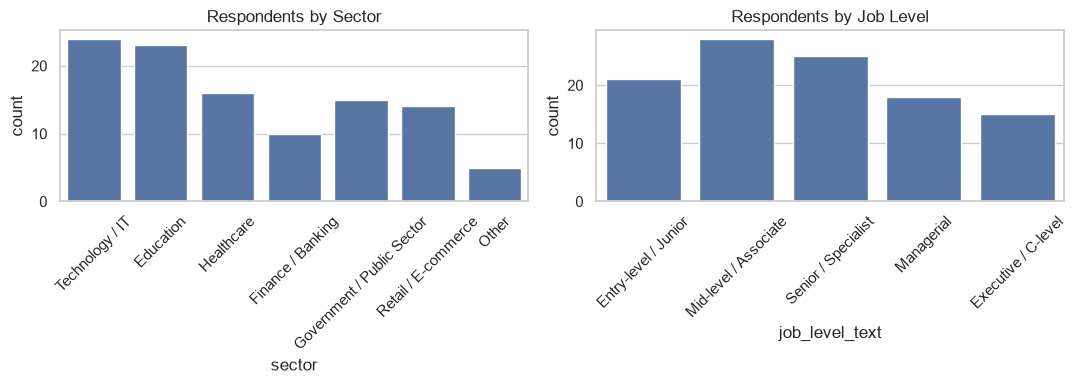

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='sector', ax=axes[0])
axes[0].set_title('Respondents by Sector')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='job_level_text', order=['Entry-level / Junior','Mid-level / Associate','Senior / Specialist','Managerial','Executive / C-level'], ax=axes[1])
axes[1].set_title('Respondents by Job Level')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/sample_distribution.png', dpi=150)
plt.show()

## 5. Correlation analysis

In [8]:
corr = run_correlations(df, key_vars)
corr

,ai_usage_freq,ai_literacy,productivity_index,anxiety_index
ai_usage_freq,1.000000,0.383797,0.877375,0.904675
ai_literacy,0.383797,1.000000,0.436135,0.271752
productivity_index,0.877375,0.436135,1.000000,0.917842
anxiety_index,0.904675,0.271752,0.917842,1.000000


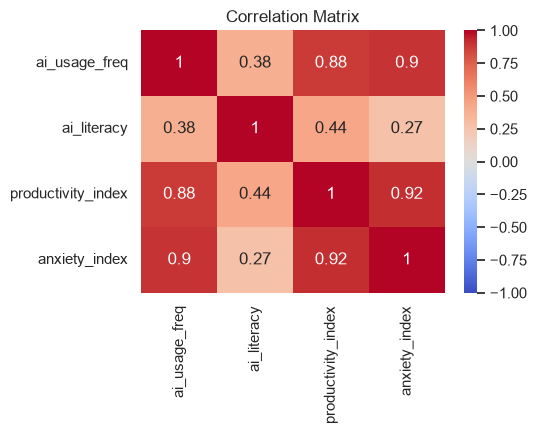

In [9]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

## 6. Group comparisons
Does productivity or anxiety differ by job level or sector?

In [10]:
print('Productivity by job_level:', run_group_anova(df, 'productivity_index', 'job_level'))
print('Anxiety by job_level:', run_group_anova(df, 'anxiety_index', 'job_level'))
print('Anxiety by sector:', run_group_anova(df, 'anxiety_index', 'sector'))

Productivity by job_level: {'f_stat': np.float64(21.0971376889309), 'p_value': np.float64(1.0692391555968774e-12)}
Anxiety by job_level: {'f_stat': np.float64(22.845548453530906), 'p_value': np.float64(1.7023159254419666e-13)}
Anxiety by sector: {'f_stat': np.float64(7.741179912760247), 'p_value': np.float64(7.545061253464098e-07)}


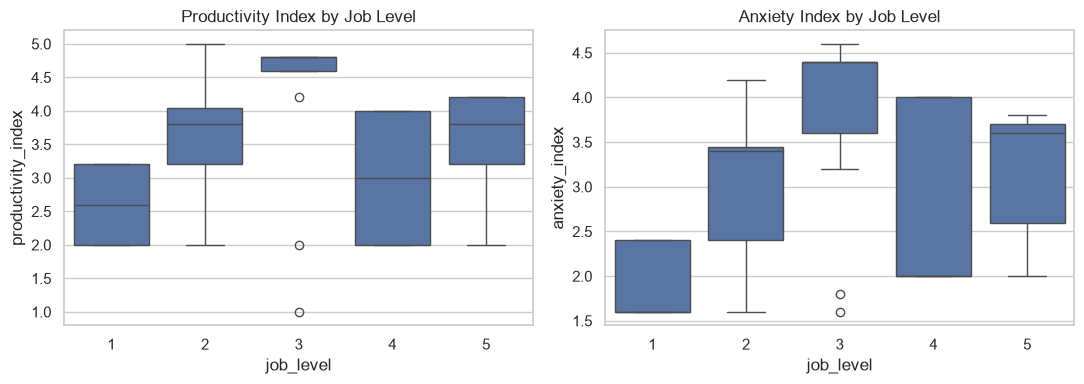

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='job_level', y='productivity_index', ax=axes[0])
axes[0].set_title('Productivity Index by Job Level')
sns.boxplot(data=df, x='job_level', y='anxiety_index', ax=axes[1])
axes[1].set_title('Anxiety Index by Job Level')
plt.tight_layout()
plt.savefig('../reports/figures/boxplots_joblevel.png', dpi=150)
plt.show()

## 7. Regression models

In [12]:
prod_model = run_regression(df, 'productivity_index ~ ai_usage_freq + ai_literacy + C(job_level)')
print(prod_model.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_index   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     63.93
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           5.05e-32
Time:                        22:07:31   Log-Likelihood:                -67.502
No. Observations:                 107   AIC:                             149.0
Df Residuals:                     100   BIC:                             167.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.5839      0.13

In [13]:
anx_model = run_regression(df, 'anxiety_index ~ ai_usage_freq + ai_literacy + C(job_level)')
print(anx_model.summary())

                            OLS Regression Results                            
Dep. Variable:          anxiety_index   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     86.92
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           2.00e-37
Time:                        22:07:31   Log-Likelihood:                -52.475
No. Observations:                 107   AIC:                             119.0
Df Residuals:                     100   BIC:                             137.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.1691      0.11

## 8. Scatterplot: usage frequency vs. indices

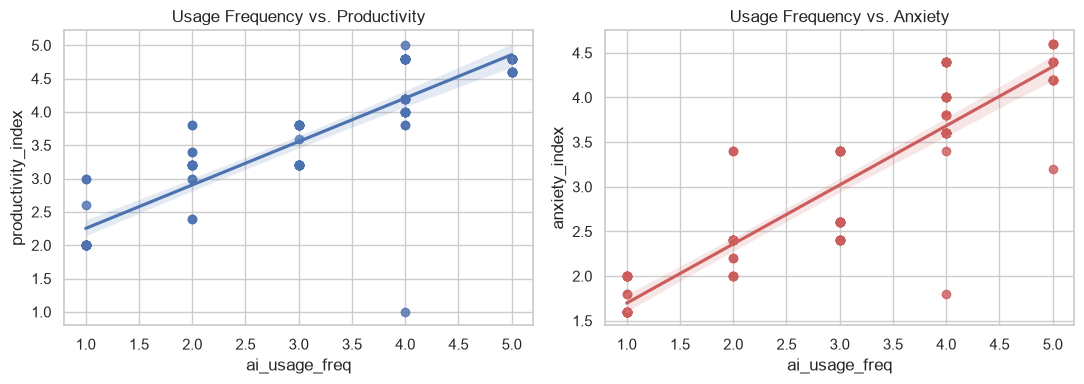

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.regplot(data=df, x='ai_usage_freq', y='productivity_index', ax=axes[0])
axes[0].set_title('Usage Frequency vs. Productivity')
sns.regplot(data=df, x='ai_usage_freq', y='anxiety_index', ax=axes[1], color='indianred')
axes[1].set_title('Usage Frequency vs. Anxiety')
plt.tight_layout()
plt.savefig('../reports/figures/scatter_usage_vs_indices.png', dpi=150)
plt.show()

## 9. Thematic coding of open-text responses (E1 / E2)

In [15]:
from collections import Counter
import re

def top_terms(series, n=10):
    words = re.findall(r'[a-zA-Z]+', ' '.join(series.dropna().astype(str)).lower())
    stop = {'the','a','an','and','to','of','my','in','is','i','for','with','about','on','at','me','it','that','may','which','has'}
    words = [w for w in words if w not in stop and len(w) > 2]
    return Counter(words).most_common(n)

print('Top terms — concerns (E1):', top_terms(df['concern_text']))
print('Top terms — benefits (E2):', top_terms(df['benefit_text']))

Top terms — concerns (E1): [('concern', 52), ('work', 33), ('automation', 29), ('could', 27), ('routine', 27), ('reduce', 26), ('change', 25), ('still', 25), ('worry', 25), ('main', 24)]
Top terms — benefits (E2): [('helps', 34), ('time', 28), ('first', 25), ('drafts', 25), ('quickly', 24), ('benefit', 23), ('summaries', 22), ('summarization', 22), ('work', 22), ('more', 22)]


## Summary
- This run uses the collected survey data (n = 107) after informed-consent filtering.
- All descriptive, correlation, ANOVA, regression, and thematic-coding results in this notebook are empirical findings from actual respondents.
- Figures are exported to `reports/figures/` for direct use in the research report and presentation slides.
- See Section 2 for data validation checks (consent filtering, range checks, missingness) run before any inferential analysis.
